Successfully loaded the data file.
Columns found: ['LR', 'INNER_DIM', 'BATCH_SIZE', 'SOFTMAX_ASSIGN', 'DECREASE_PROPORTION', 'VAL_MACRO_F1', 'VAL_ACC', 'VAL_LOSS', 'VAL_CONCEPT_COMP', 'VAL_HYBRID_SCORE', 'MODEL_PATH']

--- Best Hyperparameter Values (based on maximizing VAL_HYBRID_SCORE) ---

Analysis for LR:
  - Best value by MEAN:   0.001 (Average Score: 0.6928)
  - Best value by MEDIAN: 0.001 (Median Score: 0.6983)

Analysis for INNER_DIM:
  - Best value by MEAN:   64 (Average Score: 0.6590)
  - Best value by MEDIAN: 64 (Median Score: 0.6680)

Analysis for BATCH_SIZE:
  - Best value by MEAN:   2 (Average Score: 0.7300)
  - Best value by MEDIAN: 2 (Median Score: 0.7739)

Analysis for DECREASE_PROPORTION:
  - Best value by MEAN:   0.02 (Average Score: 0.6896)
  - Best value by MEDIAN: 0.1 (Median Score: 0.6909)

--------------------------------------------------------------------------------


--- Summary Table for DECREASE_PROPORTION ---

                     VAL_HYBRID_SCORE  VAL_MA

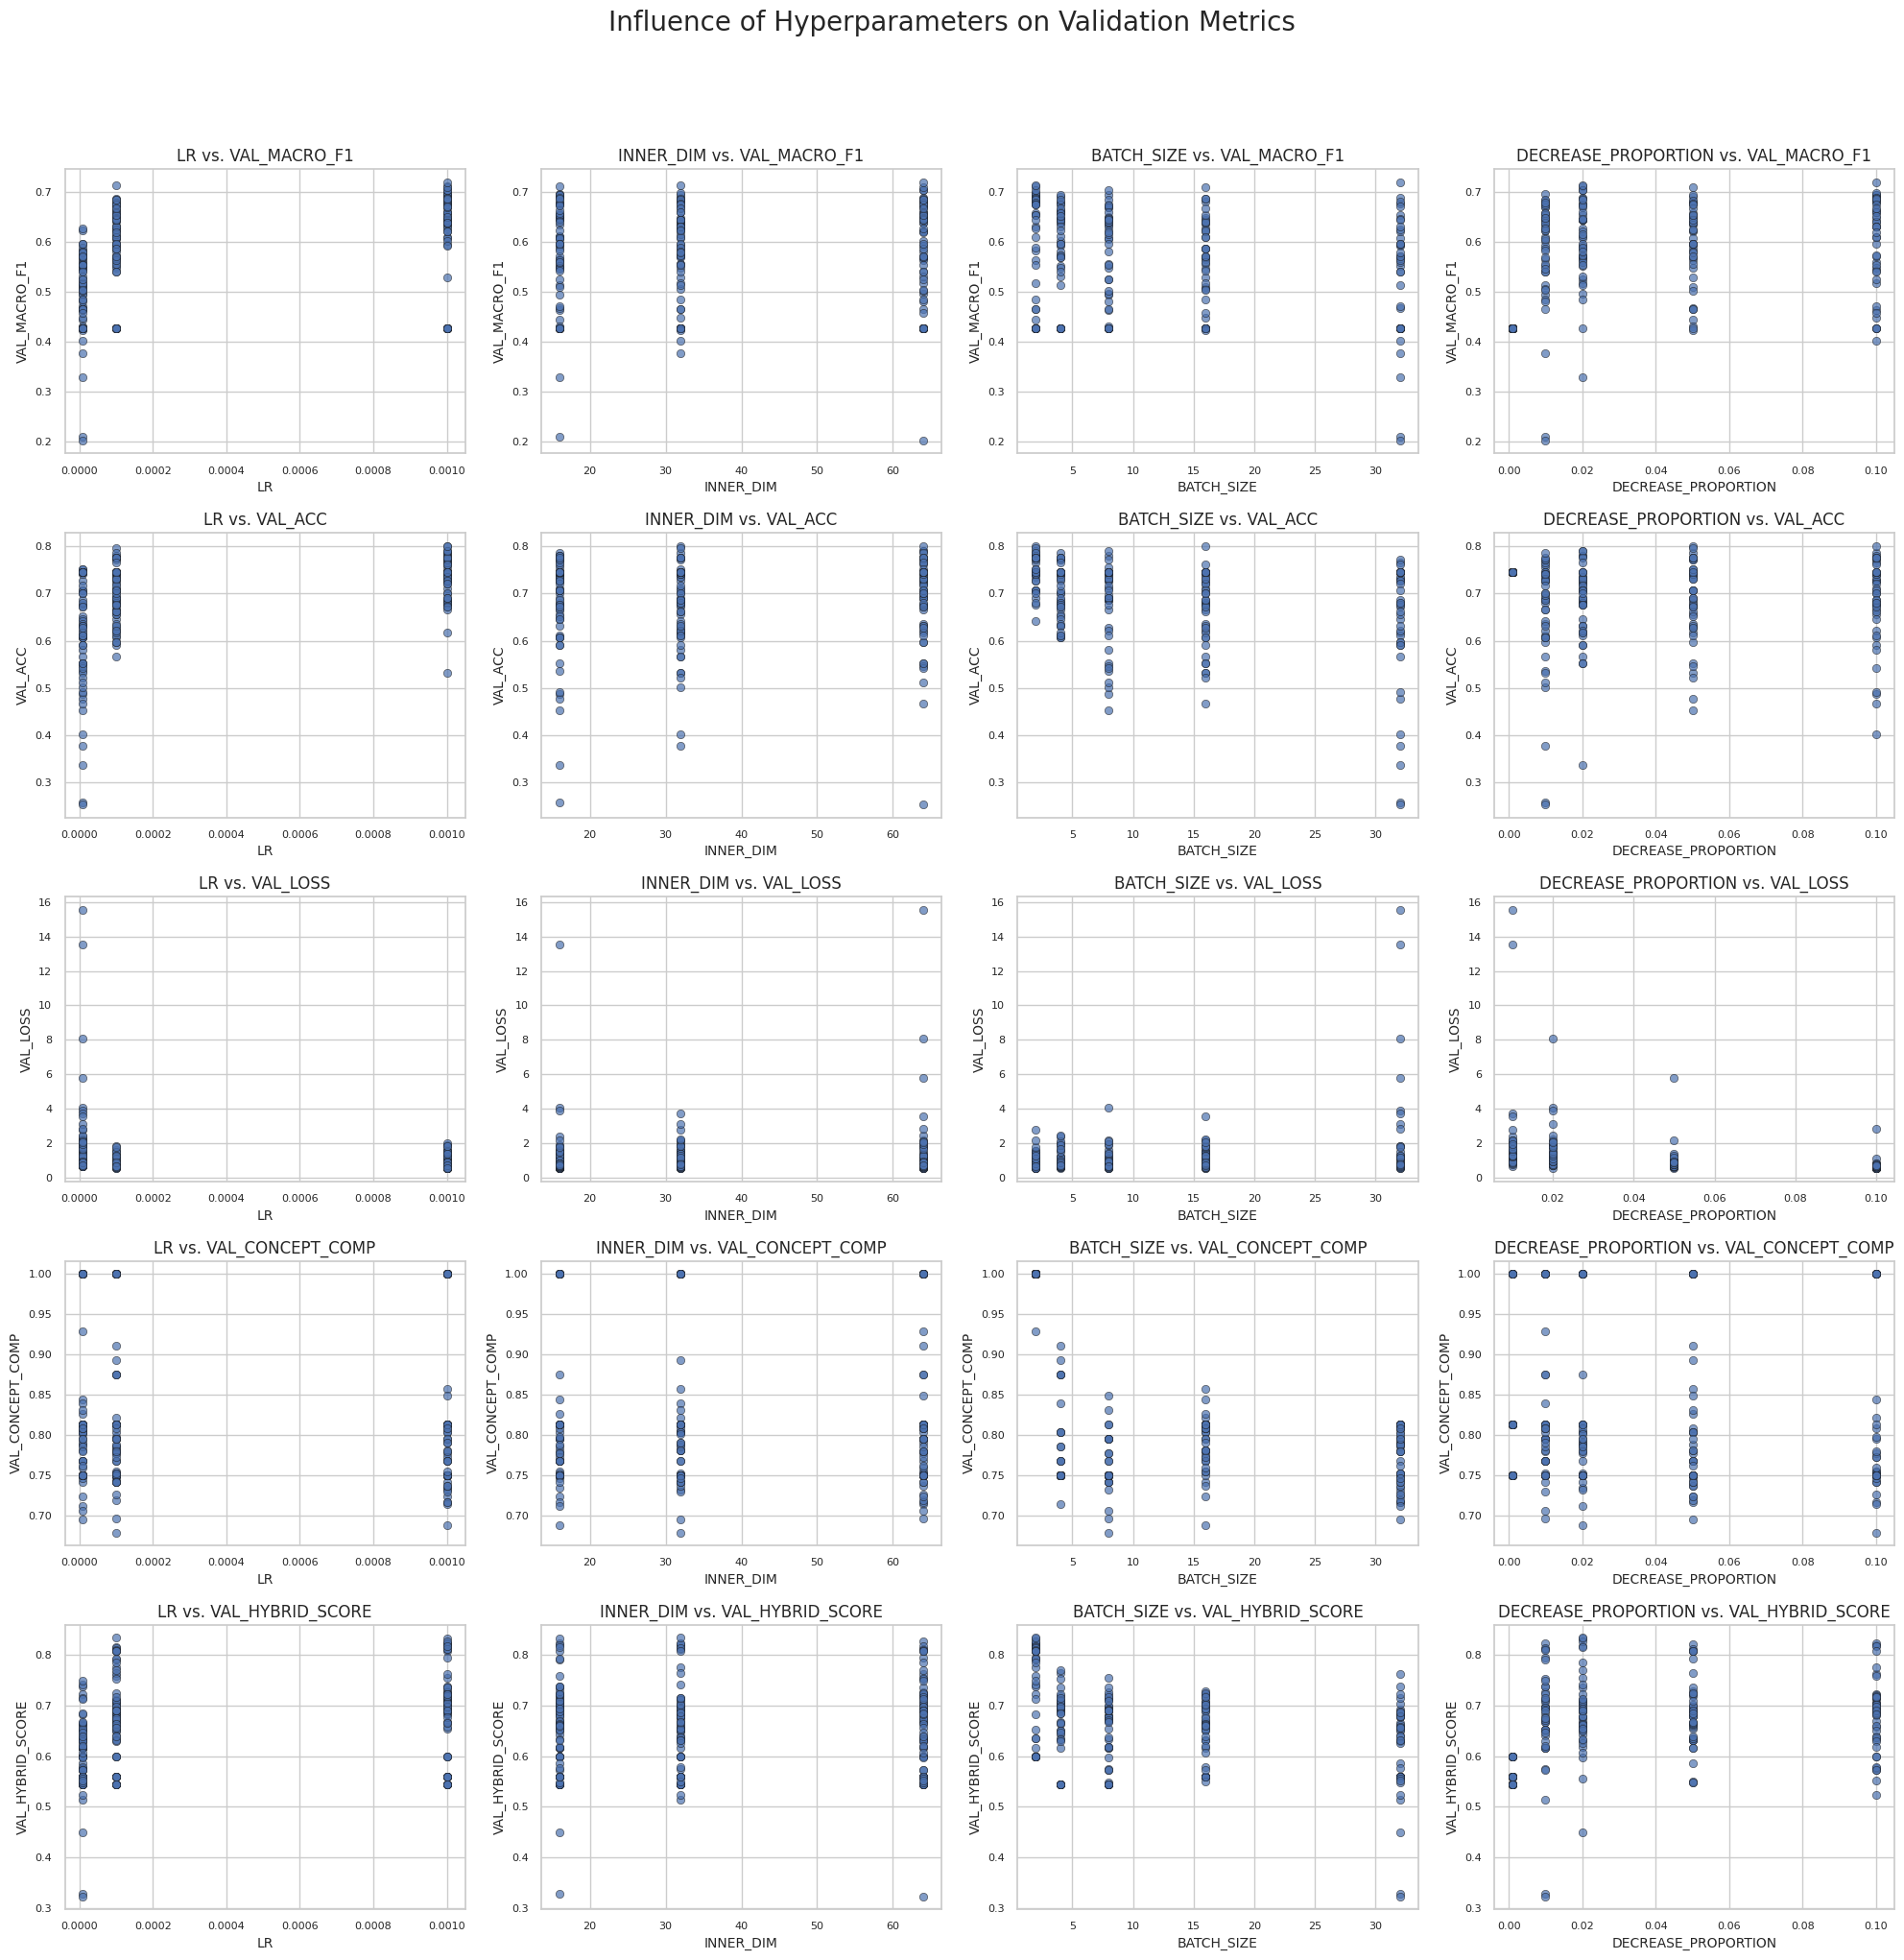

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def analyze_hyperparameter_influence(file_path):
    """
    Analyzes and visualizes the influence of hyperparameters on model metrics.

    This function reads data from an XLSX file, performs a statistical analysis
    to find the best value for each hyperparameter based on a target metric,
    and then generates scatter plots for visual inspection.

    Args:
        file_path (str): The path to the XLSX file containing the data.
    """
    try:
        # Read the data from the specified XLSX file
        df = pd.read_excel(file_path)
        print("Successfully loaded the data file.")
        print("Columns found:", df.columns.tolist())
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        print("Please make sure the file is in the same directory as the script, or provide the full path.")
        return
    except Exception as e:
        print(f"An error occurred while reading the file: {e}")
        return

    # --- Configuration ---
    # Define the independent variables (hyperparameters) you want to analyze
    independent_vars = ['LR', 'INNER_DIM', 'BATCH_SIZE', 'DECREASE_PROPORTION']

    # Define the dependent variables (metrics) you want to observe
    dependent_vars = [
        'VAL_MACRO_F1',
        'VAL_ACC',
        'VAL_LOSS',
        'VAL_CONCEPT_COMP',
        'VAL_HYBRID_SCORE'
    ]

    # Define the primary metric to optimize for finding the "best" hyperparameters
    target_metric = 'VAL_HYBRID_SCORE'

    # --- Data Validation ---
    # Check if all specified columns exist in the DataFrame
    all_vars = independent_vars + dependent_vars
    missing_cols = [col for col in all_vars if col not in df.columns]
    if missing_cols:
        print(f"Error: The following required columns are missing from the file: {missing_cols}")
        return
    if target_metric not in df.columns:
        print(f"Error: The target metric '{target_metric}' is not in the file.")
        return

    # --- Statistical Analysis ---
    print("\n--- Best Hyperparameter Values (based on maximizing VAL_HYBRID_SCORE) ---\n")
    for ind_var in independent_vars:
        # Group by the hyperparameter and calculate both the mean and median of the target metric
        try:
            # Use .agg() to calculate multiple statistics at once
            grouped_stats = df.groupby(ind_var)[target_metric].agg(['mean', 'median'])

            # Find the hyperparameter value with the highest mean score
            best_value_by_mean = grouped_stats['mean'].idxmax()
            best_mean_score = grouped_stats['mean'].max()

            # Find the hyperparameter value with the highest median score
            best_value_by_median = grouped_stats['median'].idxmax()
            best_median_score = grouped_stats['median'].max()

            print(f"Analysis for {ind_var}:")
            print(f"  - Best value by MEAN:   {best_value_by_mean} (Average Score: {best_mean_score:.4f})")
            print(f"  - Best value by MEDIAN: {best_value_by_median} (Median Score: {best_median_score:.4f})\n")


        except Exception as e:
            print(f"Could not analyze '{ind_var}'. Error: {e}\n")
    print("--------------------------------------------------------------------------------\n")

    # --- NEW: Custom Summary Table ---
    print("\n--- Summary Table for DECREASE_PROPORTION ---\n")
    try:
        # Define the columns for the summary table
        summary_metrics = ['VAL_HYBRID_SCORE', 'VAL_MACRO_F1', 'VAL_CONCEPT_COMP']

        # Group by 'DECREASE_PROPORTION' and calculate the mean for the specified metrics
        summary_table = df.groupby('DECREASE_PROPORTION')[summary_metrics].median()

        # Display the resulting table
        print(summary_table)
        print("\n-------------------------------------------------\n")

    except Exception as e:
        print(f"Could not generate the summary table. Error: {e}\n")


    # --- Visualization ---
    # Set the style for the plots for better aesthetics
    sns.set(style="whitegrid")

    # Calculate the number of rows and columns for the subplot grid
    num_ind_vars = len(independent_vars)
    num_dep_vars = len(dependent_vars)

    # Create a figure and a set of subplots
    # The figure size is adjusted based on the number of plots to ensure readability
    fig, axes = plt.subplots(num_dep_vars, num_ind_vars, figsize=(num_ind_vars * 5, num_dep_vars * 4))
    fig.suptitle('Influence of Hyperparameters on Validation Metrics', fontsize=20, y=1.02)

    # --- FIXED SECTION ---
    # Ensure 'axes' is always a flattened array for easy indexing.
    # This handles cases with single rows/columns or even a single plot.
    if num_dep_vars * num_ind_vars > 1:
        axes = axes.flatten()
    else:
        # If there's only one subplot, subplots() returns a single Axes object.
        # We put it in a list to make our loop work consistently.
        axes = [axes]

    plot_index = 0
    # Iterate through each dependent and independent variable to create a scatter plot
    for dep_var in dependent_vars:
        for ind_var in independent_vars:
            # Select the correct subplot axis from our flattened array
            ax = axes[plot_index]

            # Create the scatter plot using seaborn for better visuals
            sns.scatterplot(data=df, x=ind_var, y=dep_var, ax=ax, alpha=0.7, edgecolor='k')

            # Set the title and labels for each subplot
            ax.set_title(f'{ind_var} vs. {dep_var}', fontsize=12)
            ax.set_xlabel(ind_var, fontsize=10)
            ax.set_ylabel(dep_var, fontsize=10)
            ax.tick_params(axis='both', which='major', labelsize=8)
            plot_index += 1

    # Adjust the layout to prevent titles and labels from overlapping
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    # Display the plots
    plt.show()


if __name__ == '__main__':
    # --- IMPORTANT ---
    # Replace 'your_data.xlsx' with the actual name of your XLSX file.
    # If the file is not in the same directory as this script,
    # provide the full path to the file.
    # Example for Windows: 'C:\\Users\\YourUser\\Documents\\data.xlsx'
    # Example for macOS/Linux: '/home/youruser/documents/data.xlsx'

    excel_file_path = '../gridsearch_results_STF_HC.xlsx'
    analyze_hyperparameter_influence(excel_file_path)

